In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

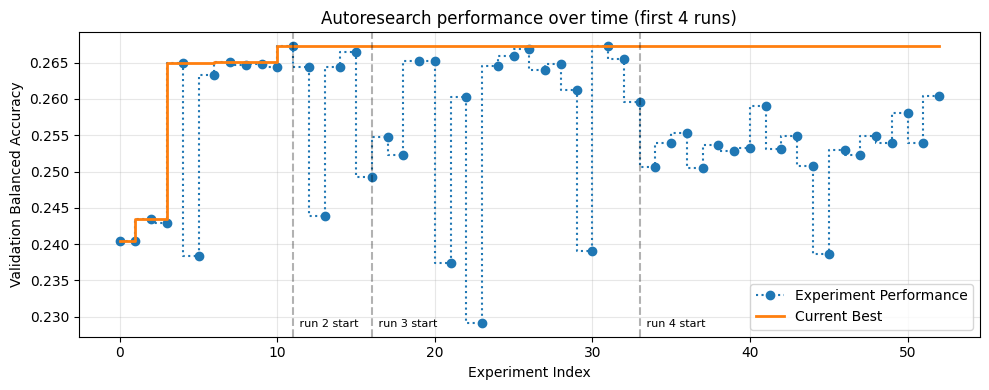

In [8]:
# Read results files (1..4) and combine val_acc in chronological order
files = [Path('../results/old') / f'{i}_run_results.tsv' for i in range(1,5)]
vals = []
for f in files:
    df = pd.read_csv(f, sep='	')
    vals.extend(df['val_acc'].tolist())

x = np.arange(len(vals))
vals = np.array(vals)
cumbest = np.maximum.accumulate(vals)

plt.figure(figsize=(10,4))
# dotted step for experiment performance (steps at left endpoint)
plt.step(x, vals, where='pre', linestyle=':', marker='o', color='C0', label='Experiment Performance')
# solid step for cumulative best
plt.step(x, cumbest, where='pre', linestyle='-', linewidth=2.0, color='C1', label='Current Best')

plt.xlabel('Experiment Index')
plt.ylabel('Validation Balanced Accuracy')
plt.title('Autoresearch performance over time (first 4 runs)')
plt.grid(alpha=0.3)
plt.legend()

# mark vertical separators between runs
run_counts = [len(pd.read_csv(Path('../results/old/') / f'{i}_run_results.tsv', sep='	')) for i in range(1,5)]
sep = 0
for i, c in enumerate(run_counts[:-1], start=1):
    sep += c
    plt.axvline(sep, color='black', linestyle='--', alpha=0.3)
    plt.text(sep+0.2, plt.ylim()[0]+0.001, f' run {i+1} start', va='bottom', ha='left', fontsize=8, color='black')

plt.tight_layout()
plt.show()

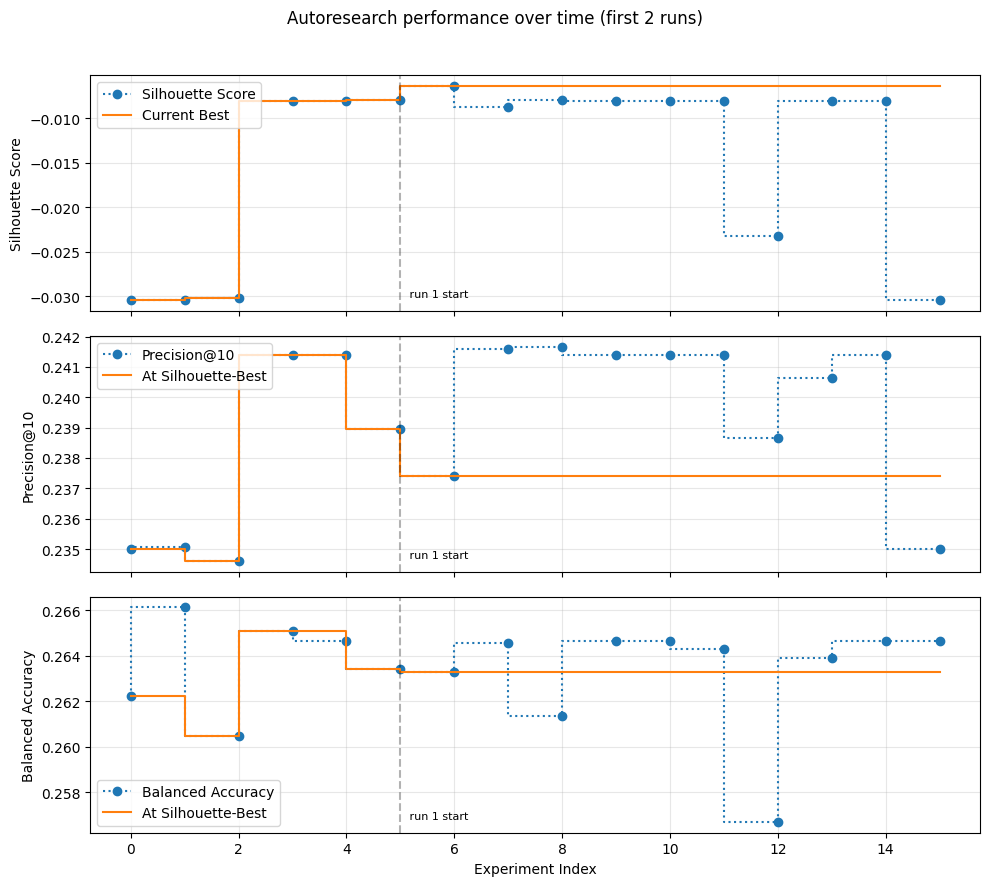

In [16]:
fpath = Path('..') / 'results' / 'results.tsv'
df = pd.read_csv(fpath, sep='	')

metrics = ['silhouette_score', 'precision@10', 'balanced_accuracy']
for col in metrics:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].replace({'---': np.nan}), errors='coerce')

x = np.arange(len(df))

# Build silhouette-driven best-index trace (best index up to each position)
sil_col = 'silhouette_score'
if sil_col in df.columns:
    sil = df[sil_col].to_numpy(dtype=float)
else:
    sil = np.full(len(df), np.nan)

best_idx = []
best_val = -np.inf
for i, val in enumerate(sil):
    if not np.isnan(val) and val > best_val:
        best_val = val
        best_idx.append(i)
    else:
        best_idx.append(best_idx[-1] if best_idx else -1)

def metric_at_best_indices(col):
    arr = df[col].to_numpy(dtype=float)
    out = np.full(len(arr), np.nan)
    for i, idx in enumerate(best_idx):
        if idx != -1 and not np.isnan(arr[idx]):
            out[i] = arr[idx]
    return out

def compute_cumbest(series):
    arr = series.to_numpy(dtype=float)
    mask = np.isnan(arr)
    arr_f = np.where(mask, -np.inf, arr)
    cumbest = np.maximum.accumulate(arr_f)
    cumbest[cumbest == -np.inf] = np.nan
    return cumbest

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plot_info = [(m, m.replace('_', ' ').title() if m != 'precision@10' else 'Precision@10') for m in metrics]

# Identify failed experiments
status_col = 'status ' if 'status ' in df.columns else ('status' if 'status' in df.columns else None)
fail_mask = (df[status_col].str.strip() == 'fail') if status_col else pd.Series(False, index=df.index)
fail_indices = np.where(fail_mask)[0]
success_indices = np.where(~fail_mask)[0]

for ax, (col, label) in zip(axes, plot_info):
    if col in df.columns:
        y = df[col].to_numpy(dtype=float).copy()
        # Plot only successful experiments
        y_success = y[success_indices]
        x_success = np.arange(len(y_success))
        
        if col == sil_col:
            cumbest = compute_cumbest(df[col])
            cumbest_success = cumbest[success_indices]
            ax.step(x_success, y_success, where='pre', linestyle=':', marker='o', color='C0', label=label)
            ax.step(x_success, cumbest_success, where='pre', linestyle='-', color='C1', linewidth=1.5, label='Current Best')
        else:
            best_series = metric_at_best_indices(col)
            best_series_success = best_series[success_indices]
            ax.step(x_success, y_success, where='pre', linestyle=':', marker='o', color='C0', label=label)
            ax.step(x_success, best_series_success, where='pre', linestyle='-', color='C1', linewidth=1.5, label='At Silhouette-Best')
        
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)
        legend_loc = 'lower left' if col == 'balanced_accuracy' else 'upper left'
        ax.legend(loc=legend_loc)
    else:
        ax.text(0.5, 0.5, f'Column {col} not found', ha='center', va='center')
        ax.set_ylabel(label)
        ax.set_xticks([])

# Add run separators based on run_id column
run_id_col = 'run_id ' if 'run_id ' in df.columns else ('run_id' if 'run_id' in df.columns else None)
if run_id_col:
    run_ids = df[run_id_col].values
    # Find indices where run_id changes (handle string comparison)
    run_changes = np.where(run_ids[:-1] != run_ids[1:])[0] + 1
    
    if len(run_changes) > 0:
        # Map run_changes to the success_indices coordinate system
        run_changes_mapped = []
        for change_idx in run_changes:
            if change_idx in success_indices:
                # Find position in success_indices
                pos = np.where(success_indices == change_idx)[0]
                if len(pos) > 0:
                    run_changes_mapped.append(pos[0])
        
        for ax in axes:
            for j, sep in enumerate(run_changes_mapped):
                ax.axvline(sep, color='black', linestyle='--', alpha=0.3)
                y_min = ax.get_ylim()[0]
                y_offset = (ax.get_ylim()[1] - y_min) * 0.05
                ax.text(sep+0.1, y_min+y_offset, f' run {j+1} start', va='bottom', ha='left', fontsize=8, color='black')

axes[-1].set_xlabel('Experiment Index')
fig.suptitle('Autoresearch performance over time (first 2 runs)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()